<a href="https://colab.research.google.com/github/TomkerDev/Projet-Segmentation-Strat-gique-des-Clients-Analyse-RFM-/blob/main/Segmentation_Strat%C3%A9gique_des_Clients_(Analyse_RFM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet : Segmentation Stratégique des Clients (Analyse RFM)

**L'objectif est de classer les clients d'une entreprise en fonction de leur comportement d'achat pour aider le département marketing.**

1. Le DatasetUtilise le dataset "Online Retail" (disponible sur UCI Machine Learning Repository ou Kaggle). Il contient des transactions réelles d'un magasin de vente au détail.

2. Les Étapes du Data Mining (Workflow)
- Nettoyage (Data Cleaning) : Gestion des valeurs manquantes, suppression des retours (quantités négatives) et conversion des types de données (dates).

- Ingénierie des caractéristiques (Feature Engineering) : Création des scores RFM :
  **Récence** : Date de la dernière commande.
  **Fréquence **: Nombre total de commandes.
 ** Montant (Monetary)** : Somme totale dépensée.
  
- Algorithme de Clustering : Utilisation de K-Means pour regrouper les clients.Utilise la méthode du "Coude" (Elbow Method) pour déterminer le nombre optimal de clusters ($k$).

- Interprétation : Identifier les segments (ex: "Champions", "Clients à risque", "Nouveaux clients").

## Étape 1 : Préparer Colab et charger les données

In [4]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



In [5]:
from google.colab import files
uploaded = files.upload() # Une fenêtre va s'ouvrir pour choisir ton fichier Online_Retail.xlsx


Saving Online Retail.xlsx to Online Retail (2).xlsx


FileNotFoundError: [Errno 2] No such file or directory: 'Online_Retail.xlsx'

In [7]:
# Charger le fichier dans une variable appelée 'df'
# Note : Si le fichier s'appelle différemment, change le nom ici
df = pd.read_excel('Online_Retail.xlsx')

# Afficher les 5 premières lignes pour vérifier que ça marche
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Étape 2 : Le grand nettoyage

In [8]:
# 1. On enlève les lignes où on ne connaît pas le client (CustomerID vide)
df = df.dropna(subset=['CustomerID'])

# 2. On enlève les quantités négatives (qui correspondent souvent à des retours/annulations)
df = df[df['Quantity'] > 0]

# 3. On crée une colonne pour le prix total de chaque achat
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

print("Nettoyage terminé ! Voici la taille de tes données propres :", df.shape)

Nettoyage terminé ! Voici la taille de tes données propres : (397924, 9)


## Étape 3 : Transformer les données en "Profils Clients" (RFM)
C'est l'étape la plus importante. On va transformer des milliers de lignes de factures en une seule ligne par client. Copie ceci dans une nouvelle cellule :

In [9]:
import datetime as dt

# On imagine que nous faisons l'analyse le lendemain de la dernière vente
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# On calcule la Récence, la Fréquence et le Montant par client
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Récence (jours)
    'InvoiceNo': 'count',                                    # Fréquence (nombre d'achats)
    'TotalSum': 'sum'                                        # Montant (argent total)
})

# On donne des noms clairs aux colonnes
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'MonetaryValue'
}, inplace=True)

rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


## Étape 4 : La Normalisation (Scaling)
L'algorithme calcule des distances. Si un client a un montant de 2000 € et une récence de 5 jours, le chiffre "2000" va écraser le chiffre "5". On va donc mettre tout le monde sur la même échelle.

In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. On utilise le Logarithme pour réduire l'écart entre les très gros clients et les petits
# Utilisation de np.log1p pour gérer les valeurs nulles ou très petites et éviter les erreurs d'infini
rfm_log = np.log1p(rfm)

# 2. On initialise le StandardScaler (il transforme les données pour que la moyenne soit 0)
scaler = StandardScaler()
rfm_normalized = scaler.fit_transform(rfm_log)

# On transforme le résultat en tableau propre (DataFrame)
rfm_normalized = pd.DataFrame(rfm_normalized, index=rfm.index, columns=rfm.columns)

print("Données normalisées (prêtes pour l'IA) :")
rfm_normalized.head()

Données normalisées (prêtes pour l'IA) :


,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,1.462236,-2.432827,3.696168
12347.0,-2.038611,1.177369,1.408758
12348.0,0.373310,-0.216521,0.715517
12349.0,-0.622914,0.453609,0.697821
12350.0,1.424800,-0.676446,-0.615877


## Étape 5 : Trouver le nombre de groupes (La méthode du Coude)
On ne sait pas encore s'il faut diviser tes clients en 3, 4 ou 5 groupes. On va demander à l'IA de tester plusieurs possibilités.

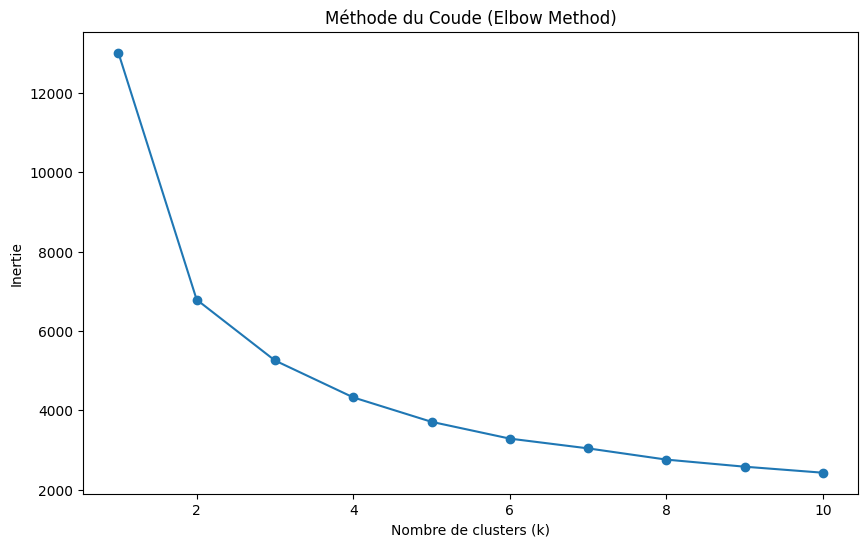

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# On teste de 1 à 10 clusters
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_normalized)
    sse[k] = kmeans.inertia_ # L'inertie mesure si les groupes sont bien compacts

# Affichage du graphique
plt.figure(figsize=(10,6))
plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du Coude (Elbow Method)")
plt.show()

## Étape 6 : Création et Analyse des Clusters
On va maintenant demander à l'IA de marquer chaque client avec son numéro de groupe (0, 1 ou 2) et de nous dire qui ils sont.

In [13]:
# 1. On lance le K-Means avec 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(rfm_normalized)

# 2. On ajoute le résultat dans notre tableau RFM d'origine
rfm['Cluster'] = kmeans.labels_

# 3. On calcule la moyenne de chaque groupe pour les comparer
analyse_clusters = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': ['mean', 'count']
}).round(0)

print(analyse_clusters)

        Recency Frequency MonetaryValue      
           mean      mean          mean count
Cluster                                      
0          66.0      61.0        1111.0  1846
1          16.0     261.0        6400.0  1003
2         177.0      15.0         297.0  1490


## 🔍 Analyse de tes segments (Clusters)

Regardons ton tableau de plus près :

- Cluster 1 : Les Champions (Les meilleurs clients) 🏆

Récence basse (16 jours) : Ils sont revenus très récemment.

Fréquence haute (261 achats) : Ils achètent tout le temps.

Montant très haut (6400 €) : Ce sont eux qui rapportent le plus.

Action marketing : Offre-leur des cadeaux exclusifs ou un programme VIP.

- Cluster 0 : Les Clients Fidèles / Moyens 👍

Récence moyenne (66 jours) et Fréquence correcte (61 achats).

Ils sont stables et rapportent environ 1111 €.

Action marketing : Envoie-leur des recommandations de produits basées sur leurs achats passés.

- Cluster 2 : Les Clients en Sommeil / À Risque ⚠️

Récence haute (177 jours) : Ils n'ont pas acheté depuis presque 6 mois.

Fréquence et Montant très bas (15 achats, 297 €).

Action marketing : Envoie-leur un gros coupon de réduction pour essayer de les faire revenir ("On vous manque ?").

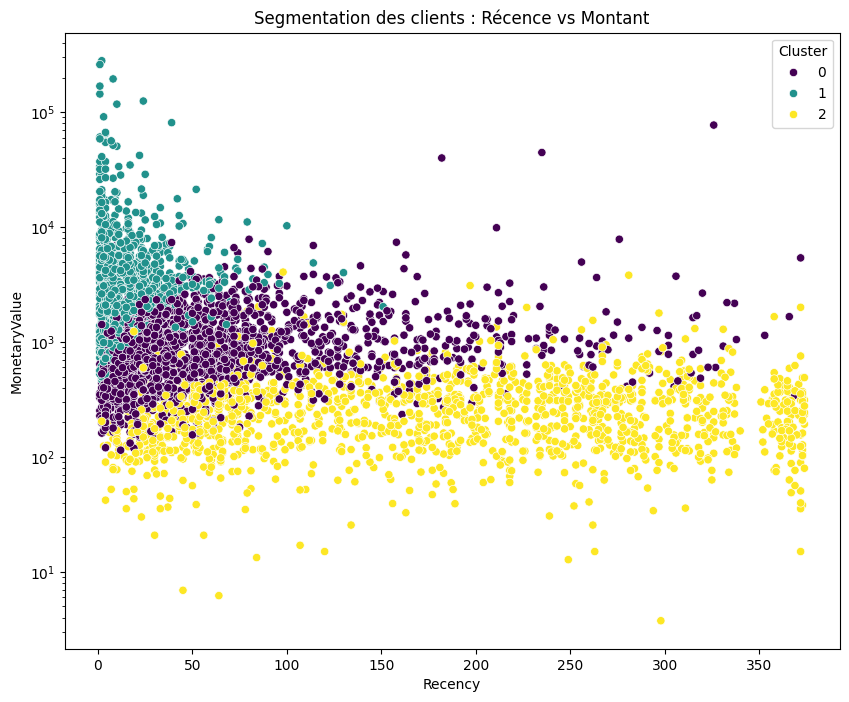

In [14]:
import seaborn as sns

# Création d'un graphique montrant la Récence vs le Montant avec les couleurs des clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=rfm, x='Recency', y='MonetaryValue', hue='Cluster', palette='viridis')
plt.title('Segmentation des clients : Récence vs Montant')
plt.yscale('log') # On utilise l'échelle log pour mieux voir les écarts de prix
plt.show()

## Conclusion & Business
Grâce à cet algorithme de Data Mining, nous avons identifié trois segments de clients distincts :

Les Champions (Cluster 1) : Clients très récents et dépensiers. Stratégie : Programme de fidélité VIP.

Les Clients Fidèles (Cluster 0) : Clients réguliers avec un panier moyen correct. Stratégie : Recommandations personnalisées.

Les Clients à Risque (Cluster 2) : Clients n'ayant pas acheté depuis longtemps (moyenne de 177 jours). Stratégie : Campagnes de réactivation avec codes promotionnels.

Using this Data Mining approach, we successfully identified three distinct customer segments:

Champions (Cluster 1): Highly active and high-spending customers. Strategy: VIP loyalty programs and exclusive previews.

Loyal Customers (Cluster 0): Regular shoppers with steady spending habits. Strategy: Cross-selling and personalized product recommendations.

At-Risk Customers (Cluster 2): Customers who haven't purchased in over 170 days on average. Strategy: "Win-back" email campaigns and significant discount offers.